Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- rdkit 2026.3.1
- ase 3.26.0
- torch 2.12.0+cu126
- torch_geometric 2.8.0
- scikit-activeml 1.0.0
- skorch 1.3.1

In [8]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import os
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import sklearn
import skorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import joblib
import skactiveml
import logging
logging.getLogger('skorch').setLevel(logging.WARNING)

from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func
from skactiveml.pool import RandomSampling
from rdkit import Chem
from sklearn.base import clone
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, Subset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SchNet
from torch.optim import Adam
from skorch import NeuralNetRegressor
from skorch.helper import predefined_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from collections import OrderedDict

from torch_geometric.nn import SchNet, radius_graph

plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Set seed for reproducibility

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
def seed_set(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_set(42)
torch.use_deterministic_algorithms(True)
generator = torch.Generator().manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
target_idx = 0

# --- Skorch wrapper ---
class InferenceDataset(Dataset):
    '''
    Returns:
      X = PyG Data object
      y = scalar target tensor
    '''

    def __init__(self, base_dataset, target_idx):
        self.base_dataset = base_dataset
        self.target_idx = target_idx

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        data = self.base_dataset[idx]

        y = data.y.view(-1, data.y.shape[-1])[0, self.target_idx].float()

        return data, y

class SchNetRegressorModule(nn.Module):
    def __init__(
        self,
        hidden_channels=64,
        num_filters=256,
        num_interactions=6,
        num_gaussians=50,
        cutoff=6.0,
        readout='add',
    ):
        super().__init__()
        self.schnet = PeriodicSchNet(
            hidden_channels=hidden_channels,
            num_filters=num_filters,
            num_interactions=num_interactions,
            num_gaussians=num_gaussians,
            cutoff=cutoff,
            readout=readout,
        ).to(device)

    def forward(self, data):
        # data is a PyG Batch object from torch_geometric.loader.DataLoader
        out = self.schnet(
            z=data.z,
            pos=data.pos,
            batch=data.batch,
            edge_index=data.edge_index,
            edge_weight=data.edge_weight,
        )

        # Make output shape [batch]
        return out.view(-1)

    def embeddings(self, data):
        z, pos, batch, edge_index, edge_weight = data[0].z.to(device), data[0].pos.to(device), data[0].batch, data[0].edge_index.to(device), data[0].edge_weight.to(device)

        row, col = edge_index
        edge_attr = self.schnet.distance_expansion(edge_weight)
    
        h = self.schnet.embedding(z)
        for interaction in self.schnet.interactions:
            h = h + interaction(h, edge_index, edge_weight, edge_attr)
    
        return self.schnet.readout(h, batch)

class PeriodicSchNet(SchNet):
    def forward(self, z, pos, batch, edge_index, edge_weight):
        
        batch = torch.zeros_like(z) if batch is None else batch
        
        h = self.embedding(z)
        edge_attr = self.distance_expansion(edge_weight)
    
        for interaction in self.interactions:
            h = h + interaction(h, edge_index, edge_weight, edge_attr)
    
        h = self.lin1(h)
        h = self.act(h)
        h = self.lin2(h)
        if self.dipole:
            # Get center of mass.
            mass = self.atomic_mass[z].view(-1, 1)
            M = self.sum_aggr(mass, batch, dim=0)
            c = self.sum_aggr(mass * pos, batch, dim=0) / M
            h = h * (pos - c.index_select(0, batch))
    
        if not self.dipole and self.mean is not None and self.std is not None:
            h = h * self.std + self.mean
    
        if not self.dipole and self.atomref is not None:
            h = h + self.atomref(z)
    
        out = self.readout(h, batch, dim=0)
    
        if self.dipole:
            out = torch.norm(out, dim=-1, keepdim=True)
    
        if self.scale is not None:
            out = self.scale * out
    
        return out
        
# --- Training and Evaluation Functions for pure PyTorch ---
from tqdm import tqdm

def train(loader, model):
    '''
    Train the model for one epoch on loader.

    Optimizes using MSE loss, and reports RMSE, MAE, and MSE
    
    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns: 
        tuple: `(rmse, mae, mse, r2)` for the epoch, or
        `(nan, nan, nan, nan)` if no valid samples are processed.
    '''
    model.train()
    total_loss = total_mae = total_samples = 0
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        if torch.isnan(true).any() or torch.isinf(true).any():
            continue
        
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            continue
        
        optimizer.zero_grad()
        mse_loss = F.mse_loss(pred, true)
        mae_loss = F.l1_loss(pred, true)
        mse_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += mse_loss.item() * data.num_graphs
        total_mae += mae_loss.item() * data.num_graphs
        total_samples += data.num_graphs
        
        y_pred.append(pred.detach().cpu())
        y_true.append(true.detach().cpu())
    y_pred = torch.cat(y_pred).numpy()
    y_true = torch.cat(y_true).numpy()
    
    if total_samples == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    
    rmse = np.sqrt(total_loss/total_samples)
    mae = total_mae/total_samples
    mse = total_loss/total_samples
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2

@torch.no_grad()
def evaluate(loader, model):
    '''
    Evaluate model on loader and compute regression metrics.

    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns:
        tuple: `(rmse, mae, mse, r2, y_true, y_pred)`, where `y_true` and
        `y_pred` are NumPy arrays containing the true and predicted values.
    '''
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        y_pred.append(pred.cpu().numpy())
        y_true.append(true.cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2, y_true, y_pred

@torch.no_grad()
def plot_prediction(dataset, model, model_name=None, name='gap', figsize=(6, 6), save=None, format='pdf', skorch=True, mean = 0, std = 1):
    '''
    Plot predicted vs. true values for model on loader.

    Computes evaluation metrics, displays a scatter plot of true versus
    predicted values with a reference diagonal, and prints MAE, MSE, RMSE,
    and R^2.

    Args:
        dataset: PyTorch Dataset (pt compatible dataset).
        model: Fitted model (torch compatible model).
        model_name: Name of the model (str).
        name: Name of the target value (str). 
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
        mean: train_dataset mean, for unscaling.
        std: train_dataset std, for unscaling.
    '''
    if skorch:
        y_true = (np.array([dataset[i].y.view(-1)[target_idx].item() for i in range(len(dataset))]).flatten()*std)+mean
        y_pred = (model.predict(InferenceDataset(dataset, target_idx=target_idx)).flatten()*std)+mean
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
    else:
        loader = DataLoader(dataset)
        rmse, mae, mse, r2, y_true, y_pred = evaluate(loader, model)
    
    errors = np.abs(y_true - y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_true, y_pred, c=errors, cmap='viridis', label='predicted values')
    ax.plot(y_true, y_true, 'r-', label='ideal')
    ax.set_xlabel(f'True {name}', fontsize=14)
    ax.set_ylabel(f'Predicted {name}', fontsize=14)
    ax.legend(facecolor='white', fontsize=14)
    if model_name is None:
        ax.set_title(f'{model.__class__.__name__} prediction plot\n{name}', fontsize=16)
    else:
        ax.set_title(f'{model_name} prediction plot\n{name}', fontsize=16)
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mae:.4f}')
    print(f'MSE = {mse:.4f}') 
    print(f'RMSE = {rmse:.4f}')
    print(f'r^2 = {r2:.4f}')

In [34]:
import py3Dmol

# Convert to CIF string
cif_str = df['structure'][10000].to(fmt="cif")

view = py3Dmol.view(width=1000, height=1000)
view.addModel(cif_str, "cif")
view.setStyle({'sphere': {'colorscheme': 'Jmol', 'scale': 0.3}, 'stick': {'colorscheme': 'Jmol', 'radius': 0.1}})
view.addUnitCell()
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [18]:
# Draw 3D structure of a molecule
import py3Dmol
from ase import Atoms
from ase.io import write
from io import StringIO


def show_ase_atoms_3d(atoms, width=500, height=400):
    buf = StringIO()
    write(buf, atoms, format='xyz')
    xyz = buf.getvalue()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, 'xyz')
    view.setStyle(
        {
            'stick': {'radius': 0.15},
            'sphere': {'scale': 0.28},
        }
    )
    view.zoomTo()
    return view.show()

dataset = torch.load('../data/qm9/qm9.pt', weights_only=False)
entry = dataset[4809]
atoms = Atoms(numbers=entry.z, positions=entry.pos)
show_ase_atoms_3d(atoms)
print(f'gap = {entry.y[4]:.4f} Ha')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

gap = 0.2199 Ha


### Load dataset

In [ ]:
from matminer.datasets import load_dataset
df = load_dataset('matbench_mp_e_form')

In [ ]:
df.head()

In [ ]:
from matminer.datasets import load_dataset
from ase.neighborlist import neighbor_list
from pymatgen.io.ase import AseAtomsAdaptor
from torch_geometric.data import Data

adaptor = AseAtomsAdaptor()

def structure_to_pyg_data(structure, y, cutoff=5.0):
    atoms = adaptor.get_atoms(structure)

    src, dst, shift = neighbor_list(
        "ijS",
        atoms,
        cutoff=cutoff,
        self_interaction=False,
    )

    pos = torch.tensor(atoms.positions, dtype=torch.float32)
    cell = torch.tensor(atoms.cell.array, dtype=torch.float32)
    shift = torch.tensor(shift, dtype=torch.float32)

    # Periodic displacement:
    # r_ij = pos_j - pos_i + shift @ cell
    edge_vec = pos[dst] - pos[src] + shift @ cell
    edge_weight = edge_vec.norm(dim=-1)

    data = Data(
        z=torch.tensor(atoms.numbers, dtype=torch.long),
        pos=pos,
        edge_index=torch.tensor(
            np.stack([src, dst]),
            dtype=torch.long,
        ),
        edge_weight=edge_weight,
        y=torch.tensor([y], dtype=torch.float32),
    )
    return data

df = load_dataset('matbench_mp_gap')
dataset = []

for i, row in df.iterrows():
    atoms = adaptor.get_atoms(row['structure'])
    y = row['gap pbe']

    src, dst, shift = neighbor_list(
        "ijS",
        atoms,
        cutoff=5.0,
        self_interaction=False,
    )

    pos = torch.tensor(atoms.positions, dtype=torch.float32)
    cell = torch.tensor(atoms.cell.array, dtype=torch.float32)
    shift = torch.tensor(shift, dtype=torch.float32)

    # Periodic displacement:
    # r_ij = pos_j - pos_i + shift @ cell
    edge_vec = pos[dst] - pos[src] + shift @ cell
    edge_weight = edge_vec.norm(dim=-1)

    data = Data(
        z=torch.tensor(atoms.numbers, dtype=torch.long),
        pos=pos,
        edge_index=torch.tensor(
            np.stack([src, dst]),
            dtype=torch.long,
        ),
        edge_weight=edge_weight,
        y=torch.tensor([y], dtype=torch.float32),
    )
    if i % 10000 == 0 and i > 0:
            print(f"Processed {i} structures...")
        
    dataset.append(data)

In [12]:
# --- Dataset Splitting ---
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import math

dataset = torch.load('../data/matbench/gap//matbench.pt', weights_only=False)

data_list = [dataset[i] for i in range(len(dataset))]
target_idx = 0
max_bins = 20

gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in data_list],
    dtype=float,
)
indices = np.arange(len(data_list))

strat_labels = None
min_count = max(2, math.ceil(2 / (0.1 + 0.1)))

for n_bins in range(max_bins, 1, -1):
    edges = np.quantile(gaps, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    if len(edges) < 3:
        continue

    candidate_labels = np.digitize(gaps, edges[1:-1], right=True)
    counts = np.bincount(candidate_labels)

    if counts.min() >= min_count:
        strat_labels = candidate_labels
        break

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=strat_labels,
)

temp_labels = strat_labels[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.1 / (0.1 + 0.1),
    random_state=42,
    stratify=temp_labels,
)

train_dataset = [data_list[i] for i in train_idx]
val_dataset = [data_list[i] for i in val_idx]
test_dataset = [data_list[i] for i in test_idx]

torch.save(train_dataset, '../data/matbench/gap/matbench_train.pt')
torch.save(val_dataset, '../data/matbench/gap/matbench_val.pt')
torch.save(test_dataset, '../data/matbench/gap/matbench_test.pt')

In [28]:
# --- Load Data ---
train_dataset = torch.load('../data/matbench/e_form/matbench_train.pt', weights_only=False)
test_dataset = torch.load('../data/matbench/e_form/matbench_test.pt', weights_only=False)
val_dataset = torch.load('../data/matbench/e_form/matbench_val.pt', weights_only=False)

# --- Scale Target Value ---
# y_train = torch.cat([d.y for d in train_dataset])
m, s = y_train.mean(), y_train.std()

for d in train_dataset: d.y.sub_(m).div_(s)
for d in val_dataset:   d.y.sub_(m).div_(s)
for d in test_dataset:  d.y.sub_(m).div_(s)

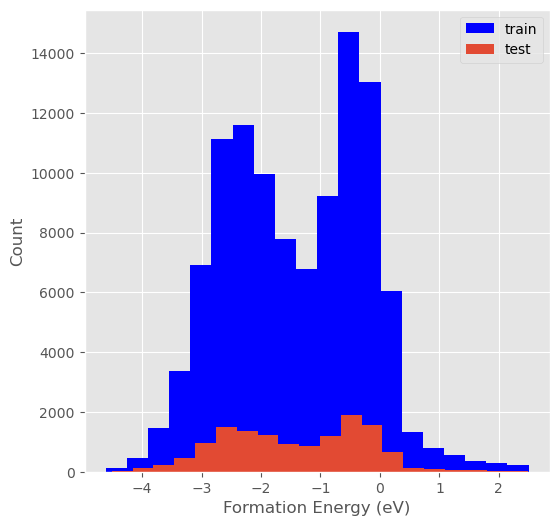

Min gap: -4.6121 eV
Max gap: 2.4995 eV
106201


In [26]:
# Plot train histogram
train_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in train_dataset],
    dtype=float,
)
plt.figure(figsize=(6, 6))
plt.hist(train_gaps, bins=20, color='blue', label='train')
plt.hist(test_gaps, bins=20, label='test')
plt.xlabel('Formation Energy (eV)')
plt.ylabel('Count')
plt.legend()
plt.savefig('eform_distribution.png', format='png', dpi=300)
plt.show()
print(f'Min gap: {train_gaps.min():.4f} eV')
print(f'Max gap: {train_gaps.max():.4f} eV')
print(len(train_dataset))

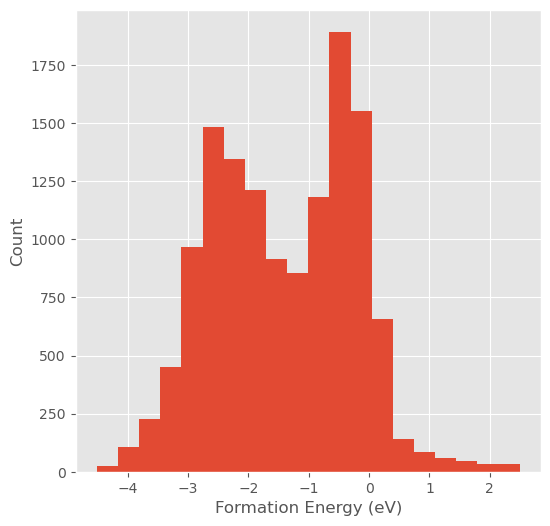

Min gap: -4.5106 eV
Max gap: 2.4938 eV
13276


In [19]:
# Plot test histogram
test_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in test_dataset],
    dtype=float,
)
plt.figure(figsize=(6, 6))
plt.hist(test_gaps, bins=20)
plt.xlabel('Formation Energy (eV)')
plt.ylabel('Count')
plt.savefig('eform_distribution_test.png', format='png', dpi=300)
plt.show()
print(f'Min gap: {test_gaps.min():.4f} eV')
print(f'Max gap: {test_gaps.max():.4f} eV')
print(len(test_dataset))

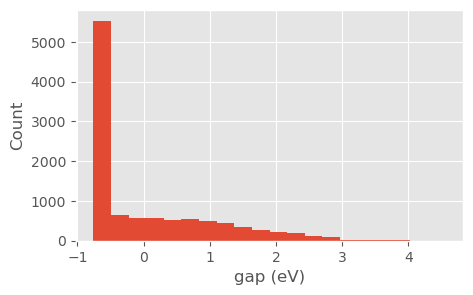

Min gap: -0.7596 eV
Max gap: 4.5653 eV


In [17]:
# Plot val histogram
val_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in val_dataset],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(val_gaps, bins=20)
plt.xlabel('gap (eV)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {val_gaps.min():.4f} eV')
print(f'Max gap: {val_gaps.max():.4f} eV')

In [14]:
print(train_dataset[0].z)

tensor([6, 6, 6, 6, 6, 6, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [3]:
# --- DataLoaders(Sample) ---
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset

train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

sample_ratio = 0.1
rng = np.random.default_rng(42)

train_n = max(1, int(len(train_dataset) * sample_ratio))
val_n = max(1, int(len(val_dataset) * sample_ratio))
test_n = max(1, int(len(test_dataset) * sample_ratio))

train_idx = rng.choice(len(train_dataset), size=train_n, replace=False)
val_idx = rng.choice(len(val_dataset), size=val_n, replace=False)
test_idx = rng.choice(len(test_dataset), size=test_n, replace=False)

train_dataset = [train_dataset[i] for i in train_idx]
val_dataset = [val_dataset[i] for i in val_idx]
test_dataset = [test_dataset[i] for i in test_idx]

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=generator)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Baseline

## Schnet

### Training

#### PyTorch

In [5]:
from torch_geometric.nn import SchNet
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create a config dictionary
config = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

# Define model
model = SchNet(
    hidden_channels=config['hidden_channels'],
    num_filters=config['num_filters'],
    num_interactions=config['num_interactions'],
    num_gaussians=config['num_gaussians'],
    cutoff=config['cutoff'],
    readout=config['readout'],
).to(device)

# Define optimizer
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Training Loop
epochs=500
counter=0
early_stopping=10

best_rmse = float('inf')
history = {'train_rmse': [], 'train_mae': [], 'train_mse': [], 'test_rmse': [], 'test_mae': [], 'test_mse': [], 'test_r2': []}

epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch', ncols=150)
for epoch in epoch_bar:
    train_rmse, train_mae, train_mse, train_r2 = train(train_loader, model)
    test_rmse, test_mae, test_mse, test_r2, test_y_true, test_y_pred  = evaluate(test_loader, model)
    
    scheduler.step(test_mse)

    # Track history
    history['train_rmse'].append(train_rmse)
    history['train_mae'].append(train_mae)
    history['train_mse'].append(train_mse)
    history['test_rmse'].append(test_rmse)
    history['test_mae'].append(test_mae)
    history['test_mse'].append(test_mse)
    history['test_r2'].append(test_r2)

    # Save best model
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        counter=0
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config
        }, 'models/schnet/schnet_gap_qm9_2.pt')
    else:
        counter+=1

    epoch_bar.set_postfix(
        train_rmse=f'{train_rmse:.4f}',
        test_rmse=f'{test_rmse:.4f}',
        best_rmse=f'{best_rmse:.4f}',
        lr=f'{optimizer.param_groups[0]['lr']:.1e}',
        paitence_counter=f'{counter}/{early_stopping}'
    )
    
    if counter >= early_stopping:
            print('Early stopping triggered.')
            break    
print(f'Best test RMSE: {best_rmse:.4f}')

df = pd.DataFrame(history)
df.to_csv('models/schnet/history_schnet_gap_qm9_2.csv', index=False)

Training: 100%|████| 500/500 [33:02:19<00:00, 237.88s/epoch, best_rmse=0.0059, lr=1.0e-06, paitence_counter=9/20, test_rmse=0.0060, train_rmse=0.0052]

Best test RMSE: 0.0059


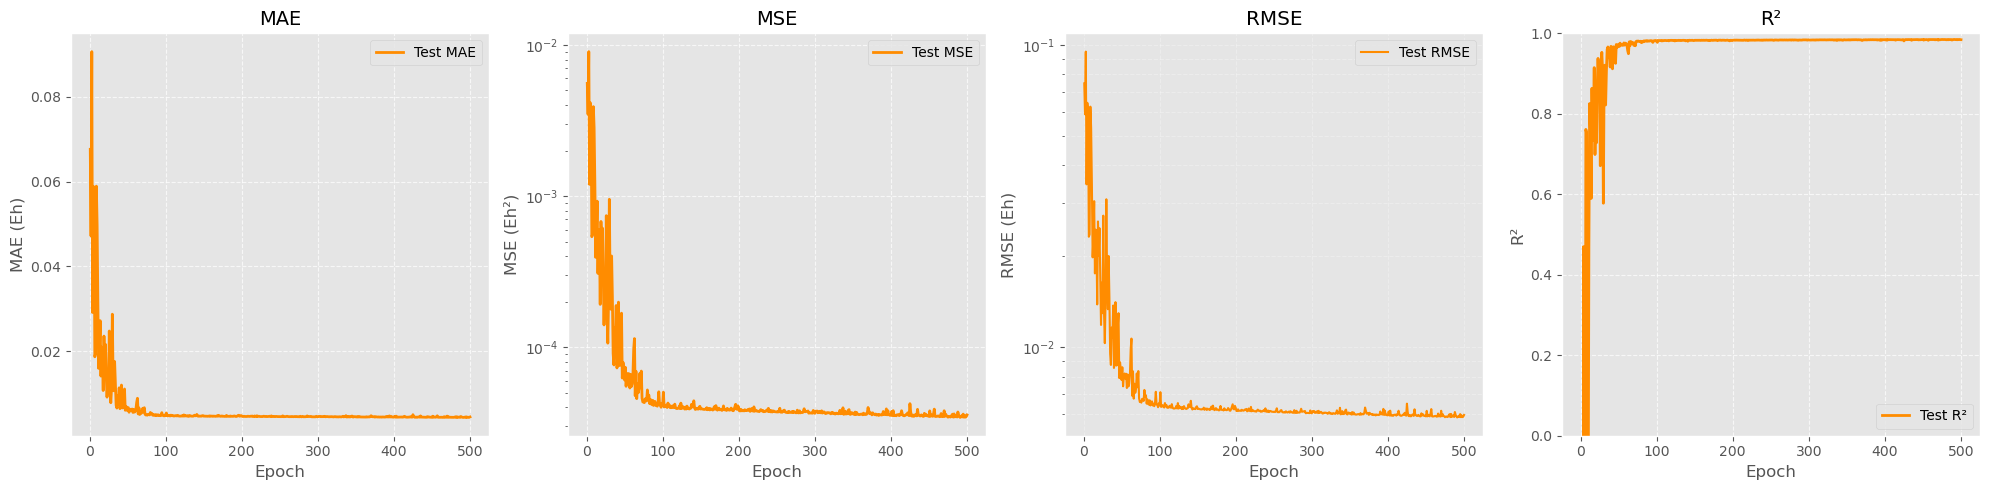

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, save=None, format='pdf'):
    epochs = range(1, len(history['train_mae']) + 1)
    
    # Create a figure with two side-by-side plots
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

    # --- Plot 1: MAE (Mean Absolute Error) ---
    ax1.plot(epochs, history['test_mae'], label='Test MAE', color='darkorange', lw=2)
    ax1.set_title('MAE', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MAE (Eh)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: MSE (Mean Squared Error) ---
    ax2.semilogy(epochs, history['test_mse'], label='Test MSE', color='darkorange', lw=2)
    ax2.set_title('MSE', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('MSE (Eh²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 3: RMSE (Log Scale) ---
    ax3.semilogy(epochs, history['test_rmse'], label='Test RMSE', color='darkorange')
    ax3.set_title('RMSE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('RMSE (Eh)')
    ax3.legend()
    ax3.grid(True, which='both', linestyle='--', alpha=0.3)

    # --- Plot 4: R2 ---
    ax4.plot(epochs, history['test_r2'], label='Test R²', color='darkorange', lw=2)
    ax4.set_title('R²', fontsize=14)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('R²', fontsize=12)
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.7)


    plt.tight_layout()
    if save is not None:
        plt.savefig(save, format=format, dpi=300)
    plt.show()

df = pd.read_csv('models/schnet/history_schnet_gap_qm9_2.csv')
history = df.to_dict(orient='list')
plot_history(history, save='models/schnet/history_schnet_gap_qm9_2.png', format='png')

#### Skorch

In [18]:
seed_set(42)
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,
    module__readout='mean',
    criterion=nn.MSELoss(),
    optimizer=torch.optim.AdamW,
    optimizer__weight_decay=1e-6,
    lr=1e-4,
    batch_size=32,
    max_epochs=150,
    iterator_train=DataLoader,
    iterator_valid=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__num_workers=0,
    iterator_valid__num_workers=0,
    train_split=predefined_split(InferenceDataset(val_dataset, target_idx=target_idx)),
    device=device,
    verbose=1,
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=20,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params='models/schnet/skorch/skorch_schnet_gap_matbench_best.pt',
            f_history='models/schnet/skorch/history_skorch_schnet_gap_matbench_best.json',
            f_criterion=None,
            f_optimizer=None,
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

model.fit(InferenceDataset(train_dataset, target_idx=target_idx), y=None)

  epoch    train_loss    valid_loss    cp      lr      dur
-------  ------------  ------------  ----  ------  -------
      1        0.4452        0.3387     +  0.0001  80.7694
      2        0.3161        0.2824     +  0.0001  80.7165
      3        0.2796        0.2629     +  0.0001  80.2990
      4        0.2556        0.2493     +  0.0001  79.3493
      5        0.2386        0.2802        0.0001  79.1510
      6        0.2253        0.2302     +  0.0001  79.1369
      7        0.2130        0.2321        0.0001  79.1923
      8        0.2040        0.2190     +  0.0001  79.1543
      9        0.1954        0.2188     +  0.0001  79.1598
     10        0.1866        0.2005     +  0.0001  79.1539
     11        0.1792        0.1986     +  0.0001  79.1367
     12        0.1919        0.1862     +  0.0001  79.1744
     13        0.1638        0.1829     +  0.0001  78.9663
     14        0.1630        0.1871        0.0001  78.3080
     15        0.1623        0.1848        0.0001  78.28

,module,<class '__mai...ressorModule'>
,criterion,MSELoss()
,optimizer,<class 'torch....adamw.AdamW'>
,lr,0.0001
,max_epochs,150
,batch_size,32
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,train_split,functools.par...7fc008bed310>)
,callbacks,"[('lr_scheduler', ...), ('early_stopping', ...), ...]"


### Model evaluation

#### Skorch
Gap
- skorch_schnet_gap_matbench_0.pt: optimizer = Adam, start learning rate = 1e-4, epochs = 100 (module__hidden_channels=128,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,)

- skorch_schnet_gap_matbench_1.pt: optimizer = Adam, start learning rate = 1e-4, decay = 1e-5, epochs = 100 (module=SchNetRegressorModule,
    module__hidden_channels=128,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,)

- skorch_schnet_gap_matbench_2.pt: optimizer = Adam, start learning rate = 1e-4, decay = 1e-5, epochs = 100 (module=SchNetRegressorModule,
    module__hidden_channels=128,
    module__num_filters=256,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,)

- skorch_schnet_gap_matbench_3.pt: optimizer = Adam, start learning rate = 1e-4, decay = 1e-5, epochs = 100 (module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,) changed PBC calculation

  
E_form
- skorch_schnet_eform_matbench_0.pt: optimizer = Adam, start learning rate = 1e-4, decay = 1e-5, epochs = 100 (module=SchNetRegressorModule,
    module__hidden_channels=128,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,)

- skorch_schnet_eform_matbench_best.pt: optimizer = Adam, start learning rate = 1e-4, decay = 1e-5, epochs = 100 (module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,) changed PBC calculation
  

In [6]:
#Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,
    module__readout='mean',
    device=device,
    iterator_valid=DataLoader,
    batch_size=32,
)

model.initialize()
model.load_params(f_params='models/schnet/skorch/skorch_schnet_eform_matbench_best.pt')

#Load w/o skorch wrapping
# checkpoint = torch.load('models/schnet/skorch/skorch_schnet_gap_qm9_1.pt', map_location=device)
# new_checkpoint = OrderedDict()
# for k, v in checkpoint.items():
#     if k.startswith('schnet.'):
#         new_checkpoint[k[len('schnet.'):]] = v
#     else:
#         new_checkpoint[k] = v
        
# conf = {
#     'hidden_channels': 64,
#     'num_filters': 256,
#     'num_interactions': 6,
#     'num_gaussians': 50,
#     'cutoff': 6.0,
#     'target_idx': 4, # 'gap'
#     'readout' : 'add',
# }

# Automatically use the saved hyperparameters
# model = SchNet(
#     hidden_channels=conf['hidden_channels'],
#     num_filters=conf['num_filters'],
#     num_interactions=conf['num_interactions'],
#     num_gaussians=conf['num_gaussians'],
#     cutoff=conf['cutoff'],
#     readout=conf.get('readout', 'add'),
# ).to(device)

# model.load_state_dict(new_checkpoint)

In [18]:
# Score of the model
true_test = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()
true_val = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()
pred_test = model.predict(InferenceDataset(test_dataset, target_idx=target_idx)).flatten()
pred_val = model.predict(InferenceDataset(val_dataset, target_idx=target_idx)).flatten()
                         
score = {
    'mae_test': mean_absolute_error(true_test, pred_test),
    'rmse_test': root_mean_squared_error(true_test, pred_test),
    'r2_test':  r2_score(true_test, pred_test),
    'mae_val': mean_absolute_error(true_val, pred_val),
    'rmse_val':  root_mean_squared_error(true_val, pred_val),
    'r2_val':   r2_score(true_val, pred_val),
}
print(score)

{'mae_test': 0.032937964383767816, 'rmse_test': 0.06280377932399521, 'r2_test': 0.9960855204589336, 'mae_val': 0.03257624331063832, 'rmse_val': 0.060880661300470734, 'r2_val': 0.996282879303744}


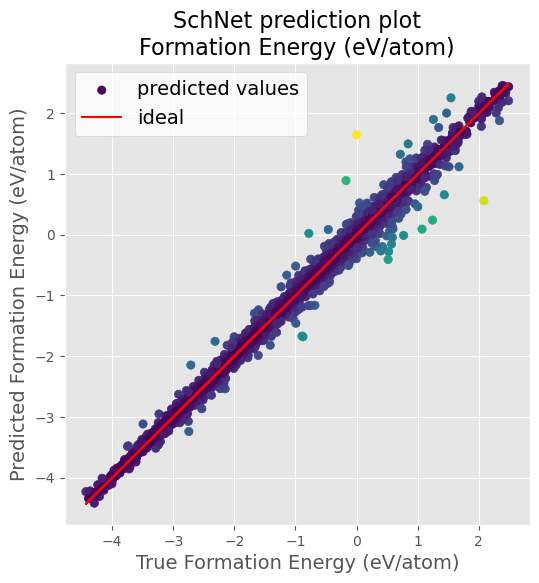

Training scores:
MAE = 0.0379
MSE = 0.0050
RMSE = 0.0708
r^2 = 0.9963


(None,)

In [29]:
plot_prediction(val_dataset, model, model_name='SchNet', name='Formation Energy (eV/atom)', mean=float(m), std=float(s)), #save='models/schnet/skorch/plot_skorch_schnet_eform_matbench_best.png', format='png')

# AL Query Strategies

In [8]:
#Random Sampling AL loop
def al_loop_rnd_skorch(
    skorch_model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    seed_set(random_state)
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)
    
    X_train_indices = np.arange(len(train_dataset)).reshape(-1, 1)
    
    # X_train = InferenceDataset(train_dataset, target_idx=target_idx)
    X_val = InferenceDataset(val_dataset, target_idx=target_idx)
    X_test = InferenceDataset(test_dataset, target_idx=target_idx)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()*float(s)+float(m)
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()*float(s)+float(m)
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # ── Query strategy ────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            X_labeled = InferenceDataset(torch.utils.data.Subset(train_dataset, labeled_idx), target_idx=target_idx)
            
            # 1. Train model utilizing skorch fit mechanics
            reg.fit(X_labeled, y=None)

            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()*float(s)+float(m)
            y_pred_val = reg.predict(X_val).flatten()*float(s)+float(m)

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            row = {
                'run':        run + 1,
                'cycle':      cycle + 1,
                'n_labeled':  n_labeled,
                'mae_test':   mae_test,
                'mse_test':   mse_test,
                'rmse_test':  rmse_test,
                'r2_test':    r2_test,
                'mae_val':    mae_val,
                'mse_val':    mse_val,
                'rmse_val':   rmse_val,
                'r2_val':     r2_val,
                'queried_idx': initial_idx.tolist() if cycle == 0 else query_idx.tolist(),
            }

            all_histories.append(row)
            if save is not None:
                pd.DataFrame(all_histories).to_csv(save, index=False)
                
            print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
            
            if len(unlabeled_idx) == 0:                
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework
            query_idx = rnd.query(
                X=X_train_indices,
                y=y_pool,
                batch_size=batch_size,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

        print(f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}')
        df = pd.DataFrame(all_histories)
        if save is not None:
            df.to_csv(save, index=False)
    return df

In [59]:
#Diversity Sampling AL loop (simple clustering of latent space)
def _resolve_to_root_indices(dataset, indices):
    """
    Map indices from the current dataset view back to the original/root dataset.

    Handles cases like:
      InferenceDataset(base_dataset=Subset(...))
      Subset(InferenceDataset(...))
      nested Subset(...)
    """
    indices = list(indices)

    if isinstance(dataset, Subset):
        mapped = [int(dataset.indices[i]) for i in indices]
        return _resolve_to_root_indices(dataset.dataset, mapped)

    if hasattr(dataset, "base_dataset"):
        return _resolve_to_root_indices(dataset.base_dataset, indices)

    return [int(i) for i in indices]

@torch.no_grad()
def get_pool_embeddings(model, pool_dataset, batch_size=64, normalize=True):
    """
    Returns
    -------
    embeddings : np.ndarray, shape [n_samples, emb_dim]
    root_indices : np.ndarray, shape [n_samples]
        Indices mapped back to the original dataset if possible.
    pool_positions : np.ndarray, shape [n_samples]
        Positions within the current pool dataset.
    """
    module = model.module_
    module.eval()

    device = next(module.parameters()).device
    loader = DataLoader(pool_dataset, batch_size=batch_size, shuffle=False)

    all_embeddings = []
    pool_positions = []
    offset = 0

    for batch in loader:
        # Your InferenceDataset returns: (data, y)
        data_batch, y_batch = batch

        # Important:
        # your embeddings() uses data[0].batch internally, so move the PyG Batch
        # itself onto the right device before passing it in.
        data_batch = data_batch.to(device)

        # Keep the exact structure expected by your current module.embeddings(...)
        emb = module.embeddings((data_batch, y_batch))

        if normalize:
            emb = F.normalize(emb, p=2, dim=-1)

        emb = emb.detach().cpu()
        all_embeddings.append(emb)

        bs = emb.size(0)
        pool_positions.extend(range(offset, offset + bs))
        offset += bs

    embeddings = torch.cat(all_embeddings, dim=0).numpy()
    pool_positions = np.asarray(pool_positions, dtype=int)
    root_indices = _resolve_to_root_indices(pool_dataset, pool_positions)

    return embeddings, root_indices, pool_positions

def kmeans_query(
    model,
    pool_dataset,
    query_size,
    batch_size=256,
    random_state=0,
    normalize=True,
):
    """
    Select a diverse batch using k-means on latent embeddings.

    Parameters
    ----------
    net : skorch.NeuralNetRegressor or nn.Module
    pool_dataset : Dataset
        Your unlabeled pool dataset.
    query_size : int
        Number of samples to query.
    batch_size : int
    random_state : int
    normalize : bool
        Whether to L2-normalize embeddings before clustering.
    return_pool_positions : bool
        If True, also return positions relative to the current pool dataset.

    Returns
    -------
    selected_root_indices : list[int]
        Selected indices mapped to the original dataset if possible.
    selected_pool_positions : list[int], optional
        Selected positions inside the current pool dataset.
    """
    X, root_indices, pool_positions = get_pool_embeddings(
        model=model,
        pool_dataset=pool_dataset,
        batch_size=batch_size,
        normalize=normalize,
    )

    root_indices = np.asarray(root_indices, dtype=int)    
    n_samples = len(X)
    if n_samples == 0 or query_size <= 0:
        return np.asarray([], dtype=int)

    query_size = min(query_size, n_samples)

    if query_size == n_samples:
        return root_indices.copy()

    kmeans = KMeans(
        n_clusters=query_size,
        n_init=1,
        random_state=random_state,
    )
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    selected_member_positions = []

    for cluster_id in range(query_size):
        members = np.where(labels == cluster_id)[0]

        if len(members) == 0:
            continue

        dists = np.linalg.norm(X[members] - centers[cluster_id], axis=1)
        best_member = members[np.argmin(dists)]
        selected_member_positions.append(best_member)

    selected_member_positions = np.asarray(selected_member_positions, dtype=int)

    return root_indices[selected_member_positions]

def al_loop_simplediv_skorch(
    skorch_model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)
    
    X_val = InferenceDataset(val_dataset, target_idx=target_idx)
    X_test = InferenceDataset(test_dataset, target_idx=target_idx)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            X_labeled = InferenceDataset(torch.utils.data.Subset(train_dataset, labeled_idx), target_idx=target_idx)
            X_unlabeled = InferenceDataset(torch.utils.data.Subset(train_dataset, unlabeled_idx), target_idx=target_idx)
            
            # 1. Train model utilizing skorch fit mechanics
            reg.fit(X_labeled, y=None)

            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()
            y_pred_val = reg.predict(X_val).flatten()

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            row = {
                'run':        run + 1,
                'cycle':      cycle + 1,
                'n_labeled':  n_labeled,
                'mae_test':   mae_test,
                'mse_test':   mse_test,
                'rmse_test':  rmse_test,
                'r2_test':    r2_test,
                'mae_val':    mae_val,
                'mse_val':    mse_val,
                'rmse_val':   rmse_val,
                'r2_val':     r2_val,
                'queried_idx': initial_idx.tolist() if cycle == 0 else query_idx.tolist(),
            }

            all_histories.append(row)
            if save is not None:
                pd.DataFrame(all_histories).to_csv(save, index=False)
                
            print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
            
            if len(unlabeled_idx) == 0:                
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework            
            query_idx = kmeans_query(
                model=reg,
                pool_dataset=X_unlabeled,
                query_size=batch_size,
                random_state=random_state,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

        print(f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}')
        df = pd.DataFrame(all_histories)
        if save is not None:
            df.to_csv(save, index=False)
    return df

In [9]:
#Diversity Sampling AL loop (clustering of latent space using TypiClust)
from skactiveml.pool import TypiClust

def _resolve_to_root_indices(dataset, indices):
    """
    Map indices from the current dataset view back to the original/root dataset.

    Handles cases like:
      InferenceDataset(base_dataset=Subset(...))
      Subset(InferenceDataset(...))
      nested Subset(...)
    """
    indices = list(indices)

    if isinstance(dataset, Subset):
        mapped = [int(dataset.indices[i]) for i in indices]
        return _resolve_to_root_indices(dataset.dataset, mapped)

    if hasattr(dataset, "base_dataset"):
        return _resolve_to_root_indices(dataset.base_dataset, indices)

    return [int(i) for i in indices]

@torch.no_grad()
def get_pool_embeddings(model, pool_dataset, batch_size=64, normalize=True):
    """
    Returns
    -------
    embeddings : np.ndarray, shape [n_samples, emb_dim]
    root_indices : np.ndarray, shape [n_samples]
        Indices mapped back to the original dataset if possible.
    pool_positions : np.ndarray, shape [n_samples]
        Positions within the current pool dataset.
    """
    module = model.module_
    module.eval()

    device = next(module.parameters()).device
    loader = DataLoader(pool_dataset, batch_size=batch_size, shuffle=False)

    all_embeddings = []
    pool_positions = []
    offset = 0

    for batch in loader:
        # Your InferenceDataset returns: (data, y)
        data_batch, y_batch = batch

        # Important:
        # your embeddings() uses data[0].batch internally, so move the PyG Batch
        # itself onto the right device before passing it in.
        data_batch = data_batch.to(device)

        # Keep the exact structure expected by your current module.embeddings(...)
        emb = module.embeddings((data_batch, y_batch))

        if normalize:
            emb = F.normalize(emb, p=2, dim=-1)

        emb = emb.detach().cpu()
        all_embeddings.append(emb)

        bs = emb.size(0)
        pool_positions.extend(range(offset, offset + bs))
        offset += bs

    embeddings = torch.cat(all_embeddings, dim=0).numpy()
    pool_positions = np.asarray(pool_positions, dtype=int)
    root_indices = _resolve_to_root_indices(pool_dataset, pool_positions)

    return embeddings, root_indices, pool_positions

def al_loop_div_skorch(
    skorch_model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    seed_set(random_state)
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    X_train = InferenceDataset(train_dataset, target_idx=target_idx)
    X_val = InferenceDataset(val_dataset, target_idx=target_idx)
    X_test = InferenceDataset(test_dataset, target_idx=target_idx)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()*float(s)+float(m)
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()*float(s)+float(m)
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # ── Query strategy ────────────────────────────────────────────────────
        qs = TypiClust(missing_label=MISSING_LABEL, random_state=random_state)

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            X_labeled = InferenceDataset(torch.utils.data.Subset(train_dataset, labeled_idx), target_idx=target_idx)
            X_unlabeled = InferenceDataset(torch.utils.data.Subset(train_dataset, unlabeled_idx), target_idx=target_idx)
            
            # 1. Train model utilizing skorch fit mechanics
            reg.fit(X_labeled, y=None)

            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()*float(s)+float(m)
            y_pred_val = reg.predict(X_val).flatten()*float(s)+float(m)

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            row = {
                'run':        run + 1,
                'cycle':      cycle + 1,
                'n_labeled':  n_labeled,
                'mae_test':   mae_test,
                'mse_test':   mse_test,
                'rmse_test':  rmse_test,
                'r2_test':    r2_test,
                'mae_val':    mae_val,
                'mse_val':    mse_val,
                'rmse_val':   rmse_val,
                'r2_val':     r2_val,
                'queried_idx': initial_idx.tolist() if cycle == 0 else query_idx.tolist(),
            }

            all_histories.append(row)
            if save is not None:
                pd.DataFrame(all_histories).to_csv(save, index=False)
                
            print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
            
            if len(unlabeled_idx) == 0:                
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework
            X_embeddings, _, _ = get_pool_embeddings(
                model=reg,
                pool_dataset=X_train,
                batch_size=256,
                normalize=True,
            )
            
            query_idx = qs.query(
                X=X_embeddings,
                y=y_pool,
                candidates=unlabeled_idx,
                batch_size=batch_size,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

        print(f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}')
        df = pd.DataFrame(all_histories)
        if save is not None:
            df.to_csv(save, index=False)
    return df

In [3]:
#Uncertainty Sampling AL loop
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted

def make_skorch_model():
    return NeuralNetRegressor(
        module=SchNetRegressorModule,
        module__hidden_channels=64,
        module__num_filters=64,
        module__num_interactions=6,
        module__num_gaussians=50,
        module__cutoff=5.0,
        module__readout="mean",
        criterion=nn.MSELoss,
        optimizer=torch.optim.Adam,
        optimizer__weight_decay=1e-6,
        optimizer__foreach=False,   # slightly lower peak memory
        lr=1e-4,
        batch_size=4,               # big one
        max_epochs=100,
        iterator_train=DataLoader,
        iterator_valid=DataLoader,
        iterator_train__shuffle=True,
        iterator_train__num_workers=0,
        iterator_valid__num_workers=0,
        iterator_valid__batch_size=8,
        device=device,
        verbose=1,
        callbacks=[
            ("lr_scheduler", LRScheduler(
                policy=ReduceLROnPlateau,
                monitor="valid_loss",
                mode="min",
                factor=0.5,
                patience=5,
                min_lr=1e-6,
            )),
            ("early_stopping", EarlyStopping(
                monitor="valid_loss",
                patience=20,
                lower_is_better=True,
                threshold=0.001,
                threshold_mode="rel",
            )),
        ],
    )
    
class IndexedSchNetRegressor(RegressorMixin, BaseEstimator):
    _estimator_type = "regressor"

    def __init__(
        self,
        skorch_model_factory,
        full_dataset,
        target_idx,
        offload_after_fit=True,
    ):
        self.skorch_model_factory = skorch_model_factory
        self.full_dataset = full_dataset
        self.target_idx = target_idx
        self.offload_after_fit = offload_after_fit

        # build once; then just take Subsets of it
        self.base_dataset = InferenceDataset(
            self.full_dataset,
            target_idx=self.target_idx,
        )

    def _to_indices(self, X):
        X = np.asarray(X)

        if X.ndim == 2 and X.shape[1] == 1:
            X = X[:, 0]

        return X.astype(np.int64, copy=False)

    def _make_dataset(self, X):
        idx = self._to_indices(X)
        return torch.utils.data.Subset(self.base_dataset, idx.tolist())

    def fit(self, X, y=None):
        ds = self._make_dataset(X)

        # create a fresh skorch net for this member
        self.model_ = self.skorch_model_factory()
        self.model_.fit(ds, y=None)

        # important: free GPU memory from already-trained members
        if self.offload_after_fit and torch.cuda.is_available():
            self.model_.module_.to("cpu")
            self.model_.device = "cpu"

            # optimizer state is not needed for predict
            if hasattr(self.model_, "optimizer_"):
                del self.model_.optimizer_

            gc.collect()
            torch.cuda.empty_cache()

        return self

    def predict(self, X):
        check_is_fitted(self, "model_")
        ds = self._make_dataset(X)
        y_pred = self.model_.predict(ds)
        return np.asarray(y_pred).reshape(-1)

def al_loop_unc_skorch(
    skorch_model,
    bagging_estimators=5,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    seed_set(random_state)
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    X_pool = np.arange(len(train_dataset)).reshape(-1, 1)
    X_train = InferenceDataset(train_dataset, target_idx=target_idx)
    X_val = InferenceDataset(val_dataset, target_idx=target_idx)
    X_test = InferenceDataset(test_dataset, target_idx=target_idx)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()*float(s)+float(m)
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()*float(s)+float(m)
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # ── Query strategy ────────────────────────────────────────────────────
        qs = QueryByCommittee(random_state=random_state)

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            X_labeled = InferenceDataset(torch.utils.data.Subset(train_dataset, labeled_idx), target_idx=target_idx)
            X_unlabeled = InferenceDataset(torch.utils.data.Subset(train_dataset, unlabeled_idx), target_idx=target_idx)
            
            # 1. Train model utilizing skorch fit mechanics
            reg.fit(X_labeled, y=None)

            ensemble = []
            
            for _ in range(bagging_estimators):
                boot_idx = run_rng.choice(
                    labeled_idx,
                    size=len(labeled_idx),
                    replace=True,
                )
            
                member = SklearnRegressor(
                    IndexedSchNetRegressor(
                        skorch_model_factory=make_skorch_model,
                        full_dataset=train_dataset,
                        target_idx=target_idx,
                        offload_after_fit=True,
                    ),
                    missing_label=MISSING_LABEL,
                )
            
                member.fit(X_pool[boot_idx], y_train_all[boot_idx])
                ensemble.append(member)
            
            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()*float(s)+float(m)
            y_pred_val = reg.predict(X_val).flatten()*float(s)+float(m)

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            row = {
                'run':        run + 1,
                'cycle':      cycle + 1,
                'n_labeled':  n_labeled,
                'mae_test':   mae_test,
                'mse_test':   mse_test,
                'rmse_test':  rmse_test,
                'r2_test':    r2_test,
                'mae_val':    mae_val,
                'mse_val':    mse_val,
                'rmse_val':   rmse_val,
                'r2_val':     r2_val,
                'queried_idx': initial_idx.tolist() if cycle == 0 else query_idx.tolist(),
            }

            all_histories.append(row)
            if save is not None:
                pd.DataFrame(all_histories).to_csv(save, index=False)
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | ', end=''
            )
            
            if len(unlabeled_idx) == 0:                
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework
            query_idx, utilities = qs.query(
                X=X_pool,
                y=y_pool,
                ensemble=ensemble,          # already fitted committee members
                fit_ensemble=False,          # important
                candidates=unlabeled_idx,    # important
                batch_size=min(batch_size, len(unlabeled_idx)),
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

            queried_utilities = utilities[0, query_idx]
            print(
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

        print(f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}')
        df = pd.DataFrame(all_histories)
        if save is not None:
            df.to_csv(save, index=False)
    return df

In [4]:
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=128,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=5.0,
    module__readout='mean',
    criterion=nn.MSELoss,
    optimizer=torch.optim.AdamW,
    optimizer__weight_decay=1e-6,
    lr=1e-4,
    batch_size=32,
    max_epochs=150,
    iterator_train=DataLoader,
    iterator_valid=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__num_workers=0,
    iterator_valid__num_workers=0,
    train_split=predefined_split(InferenceDataset(test_dataset, target_idx=target_idx)), # Pre-defined test split for validation during training
    device=device,
    verbose=1,  # Turn off standard epoch output prints from skorch
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=20,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params=None,
            f_history=None,
            f_criterion=None,
            f_optimizer=None,
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

In [12]:
results_rnd = al_loop_rnd_skorch(skorch_model=model, n_runs=1, n_initial=5000, batch_size=5000, n_cycles=10, save='active_learning/schnet/matbench/al_history_schnet_rnd_eform_matbench.csv')


Run 1/1  (seed=191664964)
  epoch    train_loss    valid_loss    cp      lr      dur
-------  ------------  ------------  ----  ------  -------
      1        0.5535        0.3460     +  0.0001  10.7810
      2        0.2809        0.2712     +  0.0001  9.4305
      3        0.2237        0.2284     +  0.0001  9.4563
      4        0.1885        0.2015     +  0.0001  9.4381
      5        0.1636        0.1821     +  0.0001  9.4303
      6        0.1445        0.1650     +  0.0001  9.4116
      7        0.1289        0.1572     +  0.0001  9.4199
      8        0.1189        0.1480     +  0.0001  9.4669
      9        0.1067        0.1376     +  0.0001  9.4637
     10        0.0970        0.1266     +  0.0001  9.4036
     11        0.0897        0.1210     +  0.0001  9.4021
     12        0.0828        0.1156     +  0.0001  9.3840
     13        0.0778        0.1096     +  0.0001  9.3879
     14        0.0716        0.1082     +  0.0001  9.3905
     15        0.0677        0.1011     + 

In [ ]:
results_div = al_loop_div_skorch(skorch_model=model, n_runs=1, n_initial=5000, batch_size=5000, n_cycles=10, save='active_learning/schnet/matbench/al_history_schnet_div_eform_matbench.csv')


Run 1/1  (seed=191664964)
  epoch    train_loss    valid_loss    cp      lr     dur
-------  ------------  ------------  ----  ------  ------
      1        0.5535        0.3460     +  0.0001  9.3717
      2        0.2809        0.2712     +  0.0001  9.3636
      3        0.2237        0.2284     +  0.0001  9.3691
      4        0.1885        0.2015     +  0.0001  9.3719
      5        0.1636        0.1821     +  0.0001  9.3686
      6        0.1445        0.1650     +  0.0001  9.3684
      7        0.1289        0.1572     +  0.0001  9.3749
      8        0.1189        0.1480     +  0.0001  9.3607
      9        0.1067        0.1376     +  0.0001  9.3681
     10        0.0970        0.1266     +  0.0001  9.3641
     11        0.0897        0.1210     +  0.0001  9.3672
     12        0.0828        0.1156     +  0.0001  9.3629
     13        0.0778        0.1096     +  0.0001  9.3690
     14        0.0716        0.1082     +  0.0001  9.3678
     15        0.0677        0.1011     +  0.

In [ ]:
results_unc = al_loop_unc_skorch(skorch_model=model, bagging_estimators=3, n_runs=1, n_initial=5000, batch_size=5000, n_cycles=10, save='active_learning/schnet/matbench/al_history_schnet_unc_eform_matbench.csv')


Run 1/1  (seed=191664964)
  epoch    train_loss    valid_loss    cp      lr      dur
-------  ------------  ------------  ----  ------  -------
      1        0.5535        0.3460     +  0.0001  10.5767
      2        0.2809        0.2712     +  0.0001  9.2455
      3        0.2237        0.2284     +  0.0001  9.2744
      4        0.1885        0.2015     +  0.0001  9.2973
      5        0.1636        0.1821     +  0.0001  9.2914
      6        0.1445        0.1650     +  0.0001  9.2882
      7        0.1289        0.1572     +  0.0001  9.3026


In [2]:
def df_groupby(df):
    '''
    Regroups the AL history df into a new df for plotting.

    Args:
        df : AL history df (pd.DataFrame)
    '''
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

def plot_al(dfs, labels, score=None, save=None, format='pdf'):
    '''
    Plot AL metrics base on labeled samples.

    Args:
        dfs : List of Data Frames modified with df_groupby (list).
        labels : List of AL strategies (list).
        score : Dictionary of metric scores of baseline model (dict).
        save : Save path (str).
        format : Save format (str).
    '''
    metrics = [
        ('mae_val', 'MAE (eV)'),
        ('rmse_val', 'RMSE (eV)'),
        ('r2_val', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key]*27.2114 if key != 'r2_val' else df[key],
                marker='o',
                color=color,
                label=name,
                linewidth=3,
            )
            # ax.fill_between(
            #     df['n_labeled'],
            #     df[f'min_{key}'],
            #     df[f'max_{key}'],
            #     alpha=0.2,
            #     color=color,
            # )

        # Plot the baseline reference line
        if score is not None:
            baseline_val = score[key]
            ax.axhline(
                baseline_val,
                color='black',
                ls='--',
                label=f'full = {baseline_val:.4f}',
                linewidth=2,
            )
            
        ax.set_xscale('log')
        ax.set_title(label, fontsize=16)
        ax.set_xlabel('Labeled samples', fontsize=16)
        ax.set_ylabel(label, fontsize=16)
        ax.legend(facecolor='white', fontsize=14)
        ax.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

In [3]:
rnd = df_groupby(pd.read_csv('active_learning/schnet/matbench/al_history_schnet_rnd_eform_matbench.csv'))

In [4]:
div = df_groupby(pd.read_csv('active_learning/schnet/matbench/al_history_schnet_div_eform_matbench.csv'))

In [8]:
unc = df_groupby(pd.read_csv('active_learning/schnet/qm9/al_history_schnet_unc_gap_qm9.csv'))

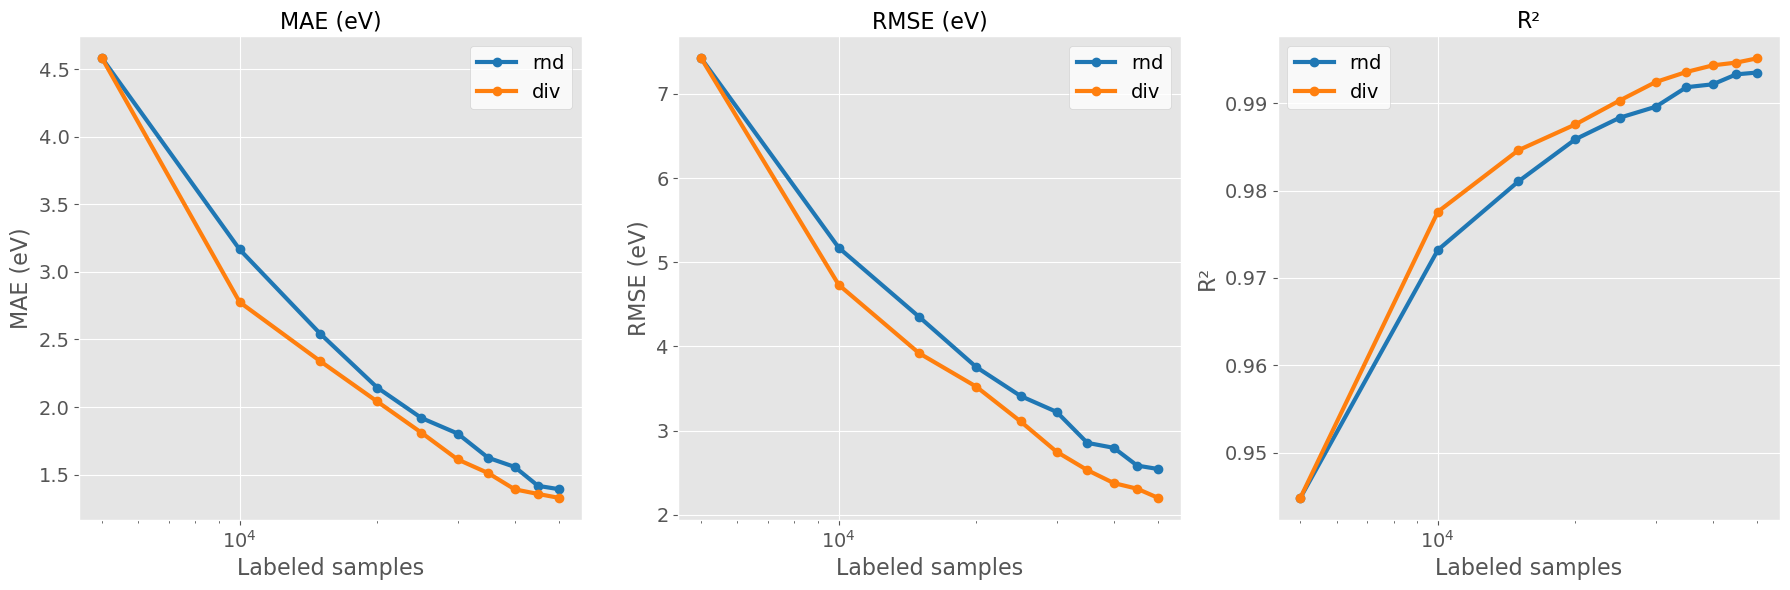

In [5]:
plot_al([rnd, div], ['rnd', 'div'], score=None)